In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#  Food Wastage Prediction — Machine Learning
**Target**: `Wastage Food Amount` (Regresi)  
**Dataset**: `food_wastage_data.csv` — 1.782 baris, 11 kolom  
**Model Terbaik**: Gradient Boosting (R² = 0.93)


## 1. Import Library & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json, joblib
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Please update the path below to the actual location of your CSV file in Google Drive
df = pd.read_csv('/content/drive/MyDrive/food_wastage_data.csv')
print('Shape :', df.shape)
print('Missing:', df.isnull().sum().sum())
df.head()

Shape : (1782, 11)
Missing: 0


,Type of Food,Number of Guests,Event Type,Quantity of Food,Storage Conditions,Purchase History,Seasonality,Preparation Method,Geographical Location,Pricing,Wastage Food Amount
0,Meat,310,Corporate,450,Refrigerated,Regular,All Seasons,Buffet,Urban,Low,25
1,Meat,400,Birthday,500,Room Temperature,Regular,Winter,Buffet,Suburban,High,40
2,Vegetables,302,Birthday,371,Refrigerated,Regular,Summer,Buffet,Suburban,Low,27
3,Meat,491,Birthday,497,Refrigerated,Regular,All Seasons,Finger Food,Rural,High,32
4,Meat,300,Corporate,400,Refrigerated,Regular,Winter,Finger Food,Urban,Moderate,25


## 2. Exploratory Data Analysis

In [ ]:
df.describe().round(2)

,Number of Guests,Quantity of Food,Wastage Food Amount
count,1782.00,1782.00,1782.00
mean,317.80,411.13,28.54
std,67.83,65.20,10.46
min,207.00,280.00,10.00
25%,267.00,350.00,20.00
50%,302.00,400.00,26.50
75%,350.00,480.00,35.00
max,491.00,500.00,63.00


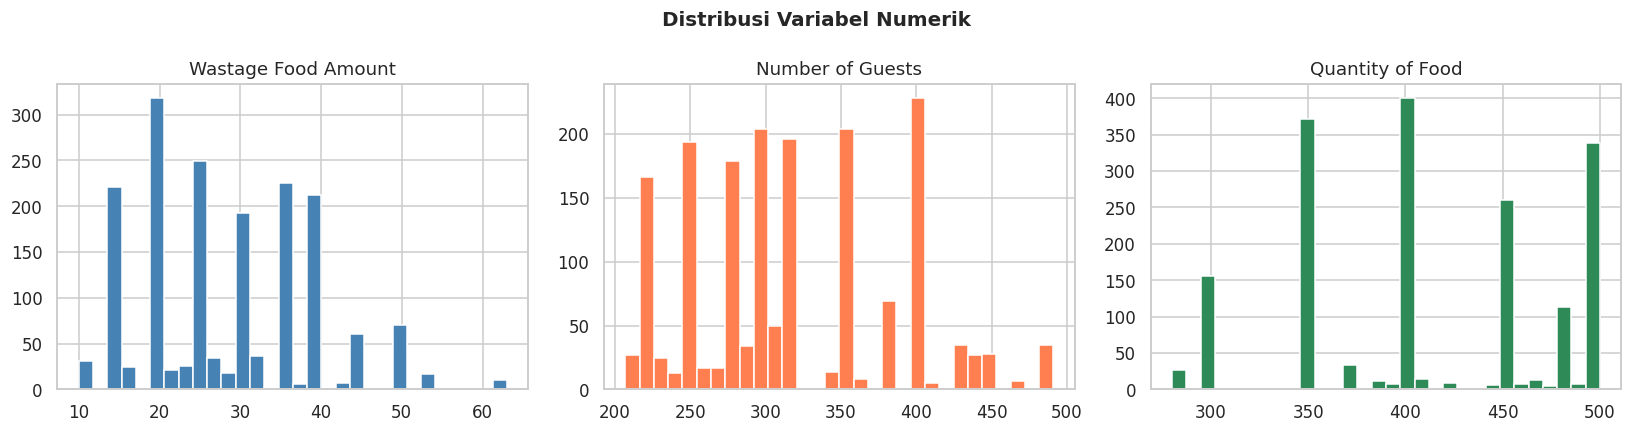

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribusi Variabel Numerik', fontsize=13, fontweight='bold')

for ax, col, color in zip(axes,
    ['Wastage Food Amount','Number of Guests','Quantity of Food'],
    ['steelblue','coral','seagreen']):
    ax.hist(df[col], bins=30, color=color, edgecolor='white')
    ax.set_title(col)

plt.tight_layout()
plt.show()

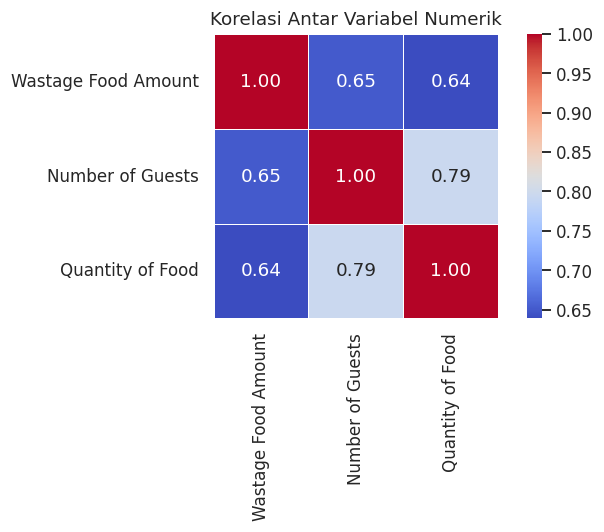

Korelasi ke target:
Wastage Food Amount    1.000000
Number of Guests       0.650421
Quantity of Food       0.638648
Name: Wastage Food Amount, dtype: float64


In [ ]:
# Korelasi
plt.figure(figsize=(7, 5))
corr = df[['Wastage Food Amount','Number of Guests','Quantity of Food']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=.5)
plt.title('Korelasi Antar Variabel Numerik')
plt.tight_layout()
plt.show()
print('Korelasi ke target:')
print(corr['Wastage Food Amount'].sort_values(ascending=False))

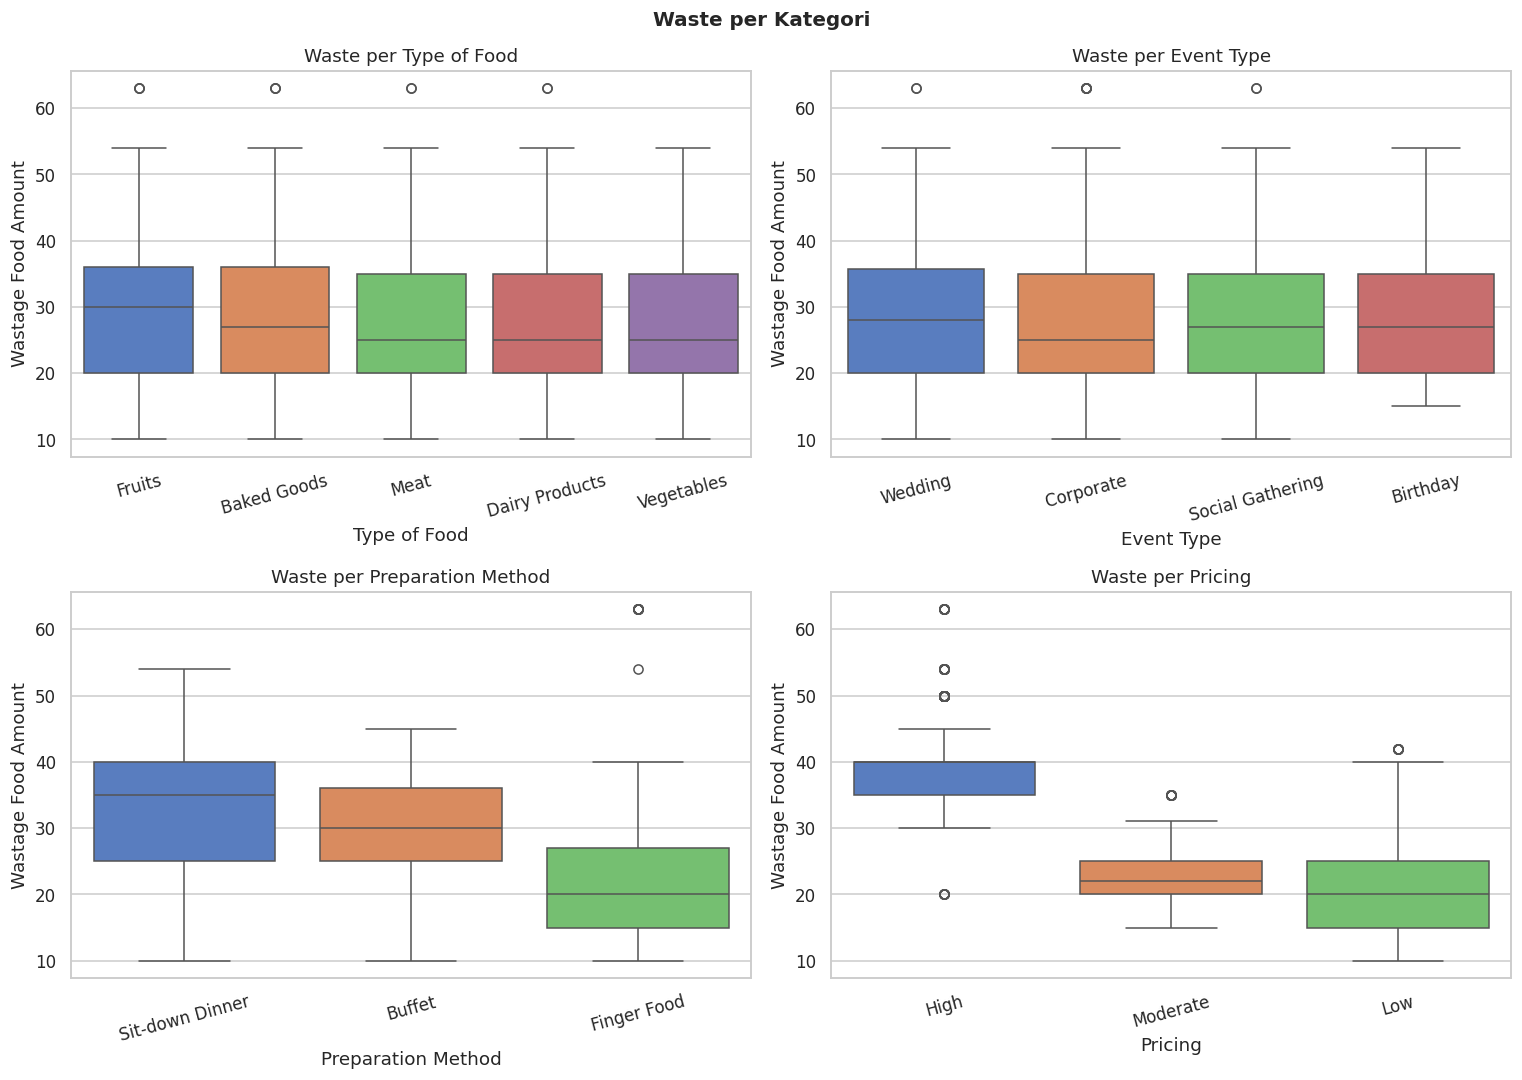

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Waste per Kategori', fontsize=13, fontweight='bold')

cat_cols = ['Type of Food','Event Type','Preparation Method','Pricing']
for ax, col in zip(axes.flat, cat_cols):
    order = df.groupby(col)['Wastage Food Amount'].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Wastage Food Amount', order=order, ax=ax, palette='muted')
    ax.set_title(f'Waste per {col}')
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [ ]:
CATEGORICAL = [
    'Type of Food', 'Event Type', 'Storage Conditions',
    'Purchase History', 'Seasonality', 'Preparation Method',
    'Geographical Location', 'Pricing'
]

le_dict = {}
df_ml = df.copy()
for col in CATEGORICAL:
    le = LabelEncoder()
    df_ml[col+'_enc'] = le.fit_transform(df_ml[col])
    le_dict[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

FEATURES = [c+'_enc' for c in CATEGORICAL] + ['Number of Guests', 'Quantity of Food']
TARGET   = 'Wastage Food Amount'

X = df_ml[FEATURES]
y = df_ml[TARGET]
print(f'\nJumlah fitur : {len(FEATURES)}')
print(f'Shape X      : {X.shape}')

Type of Food: {'Baked Goods': np.int64(0), 'Dairy Products': np.int64(1), 'Fruits': np.int64(2), 'Meat': np.int64(3), 'Vegetables': np.int64(4)}
Event Type: {'Birthday': np.int64(0), 'Corporate': np.int64(1), 'Social Gathering': np.int64(2), 'Wedding': np.int64(3)}
Storage Conditions: {'Refrigerated': np.int64(0), 'Room Temperature': np.int64(1)}
Purchase History: {'Occasional': np.int64(0), 'Regular': np.int64(1)}
Seasonality: {'All Seasons': np.int64(0), 'Summer': np.int64(1), 'Winter': np.int64(2)}
Preparation Method: {'Buffet': np.int64(0), 'Finger Food': np.int64(1), 'Sit-down Dinner': np.int64(2)}
Geographical Location: {'Rural': np.int64(0), 'Suburban': np.int64(1), 'Urban': np.int64(2)}
Pricing: {'High': np.int64(0), 'Low': np.int64(1), 'Moderate': np.int64(2)}

Jumlah fitur : 10
Shape X      : (1782, 10)


## 4. Split Data & Perbandingan Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} baris')
print(f'Test  : {X_test.shape[0]} baris')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    cv   = -cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error').mean()
    print(f'[{name}] RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f} | CV-RMSE={cv:.4f}')
    return {'Model':name,'RMSE':rmse,'MAE':mae,'R2':r2,'CV_RMSE':cv,
            'y_pred':y_pred,'object':model}

results = []
results.append(evaluate('LinearRegression',  LinearRegression()))
results.append(evaluate('Ridge',             Ridge(alpha=1.0)))
results.append(evaluate('RandomForest',      RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=4, random_state=42, n_jobs=-1)))
results.append(evaluate('GradientBoosting',  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)))
results.append(evaluate('XGBoost',           xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)))

Train : 1425 baris
Test  : 357 baris
[LinearRegression] RMSE=6.0744 | MAE=4.7449 | R²=0.6440 | CV-RMSE=6.1218
[Ridge] RMSE=6.0744 | MAE=4.7444 | R²=0.6440 | CV-RMSE=6.1217
[RandomForest] RMSE=2.9086 | MAE=1.9753 | R²=0.9184 | CV-RMSE=3.1999
[GradientBoosting] RMSE=2.7232 | MAE=1.8857 | R²=0.9285 | CV-RMSE=2.9706
[XGBoost] RMSE=2.7461 | MAE=1.8923 | R²=0.9272 | CV-RMSE=3.1063


## 5. Perbandingan Performa Model

In [ ]:
res_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_pred','object')}
                        for r in results]).sort_values('RMSE')
print(res_df.to_string(index=False))

           Model     RMSE      MAE       R2  CV_RMSE
GradientBoosting 2.723203 1.885747 0.928458 2.970587
         XGBoost 2.746127 1.892266 0.927249 3.106254
    RandomForest 2.908587 1.975305 0.918386 3.199949
           Ridge 6.074360 4.744363 0.644042 6.121678
LinearRegression 6.074406 4.744874 0.644036 6.121813


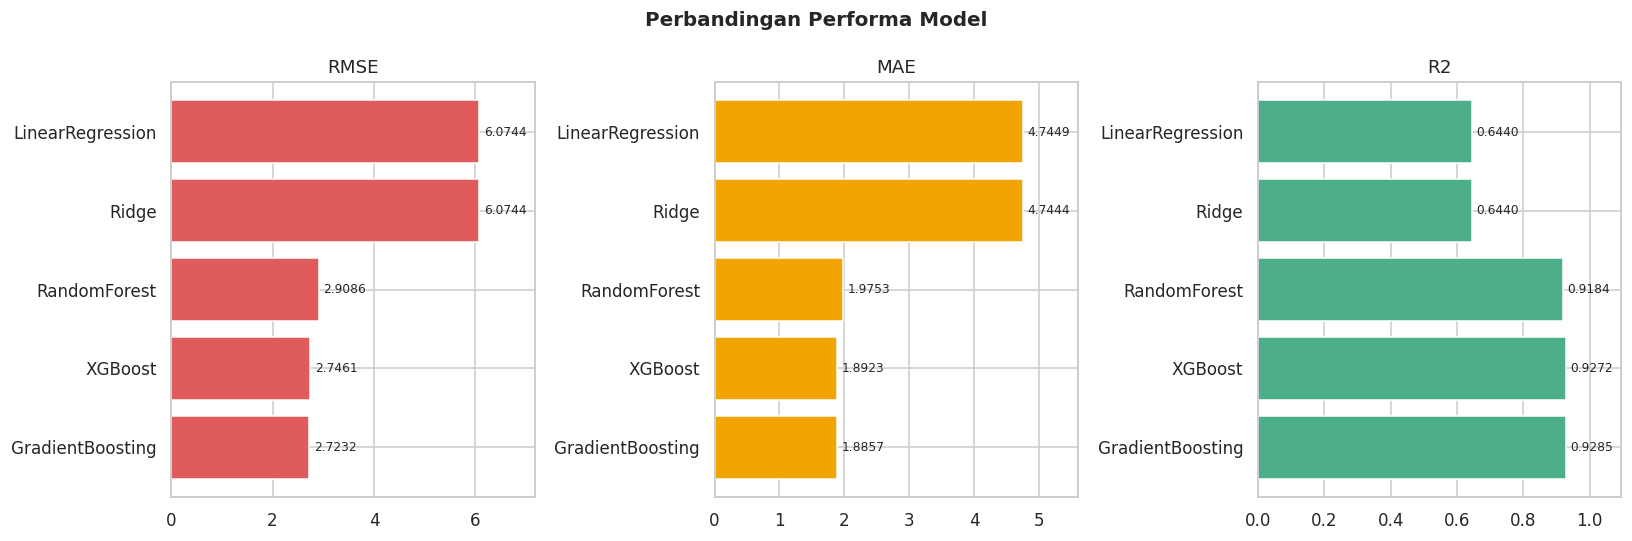

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Perbandingan Performa Model', fontsize=13, fontweight='bold')

for ax, metric, color in zip(axes,
    ['RMSE','MAE','R2'], ['#e05c5c','#f0a500','#4caf8a']):
    s = res_df.sort_values(metric, ascending=(metric != 'R2'))
    bars = ax.barh(s['Model'], s[metric], color=color, edgecolor='white')
    ax.set_title(metric)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
    ax.set_xlim(0, s[metric].max() * 1.18)

plt.tight_layout()
plt.show()

## 6. Model Terbaik — Analisis Mendalam

In [ ]:
best = min(results, key=lambda r: r['RMSE'])
print(f"Model terbaik : {best['Model']}")
print(f"  RMSE        = {best['RMSE']:.4f}")
print(f"  MAE         = {best['MAE']:.4f}")
print(f"  R²          = {best['R2']:.4f}")

best_model  = best['object']
y_pred_best = best['y_pred']

Model terbaik : GradientBoosting
  RMSE        = 2.7232
  MAE         = 1.8857
  R²          = 0.9285


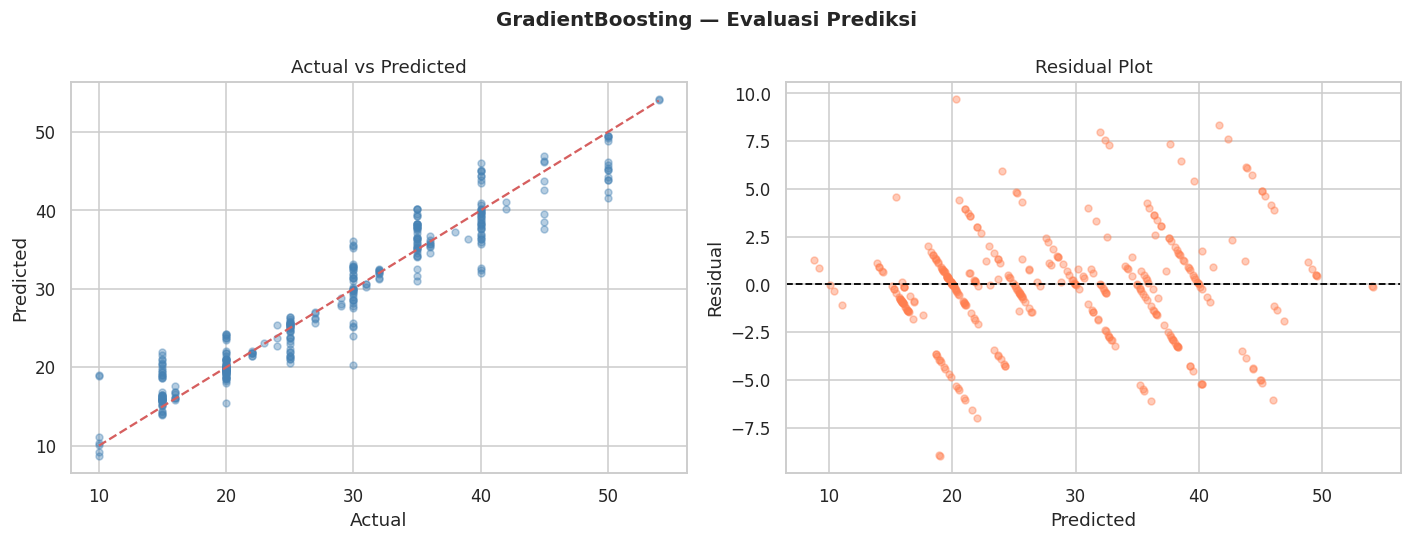

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"{best['Model']} — Evaluasi Prediksi", fontsize=13, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', s=20)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx],'r--', linewidth=1.5)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title('Actual vs Predicted')

# Residual
residuals = y_test.values - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

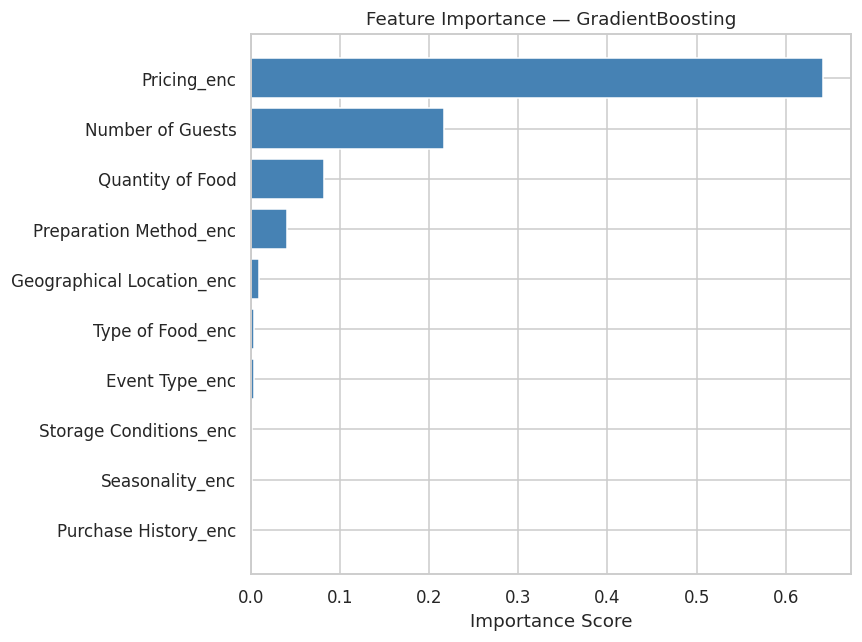

                  Feature  Importance
              Pricing_enc    0.641544
         Number of Guests    0.217114
         Quantity of Food    0.081715
   Preparation Method_enc    0.040037
Geographical Location_enc    0.008952
         Type of Food_enc    0.003313
           Event Type_enc    0.003155
   Storage Conditions_enc    0.001763
          Seasonality_enc    0.001594
     Purchase History_enc    0.000813


In [ ]:
# Feature Importance
importances = best_model.feature_importances_
fi_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', edgecolor='white')
plt.title(f'Feature Importance — {best["Model"]}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))

## 7. Simpan Model

In [ ]:
os.makedirs('model', exist_ok=True)

joblib.dump(best_model, 'model/food_waste_model.pkl')
joblib.dump(le_dict,    'model/label_encoders.pkl')

metadata = {
    'model_name'                  : best['Model'],
    'features'                    : FEATURES,
    'target'                      : TARGET,
    'rmse'                        : round(best['RMSE'], 4),
    'mae'                         : round(best['MAE'],  4),
    'r2'                          : round(best['R2'],   4),
    'type_of_food_classes'        : list(le_dict['Type of Food'].classes_),
    'event_type_classes'          : list(le_dict['Event Type'].classes_),
    'storage_conditions_classes'  : list(le_dict['Storage Conditions'].classes_),
    'purchase_history_classes'    : list(le_dict['Purchase History'].classes_),
    'seasonality_classes'         : list(le_dict['Seasonality'].classes_),
    'preparation_method_classes'  : list(le_dict['Preparation Method'].classes_),
    'geographical_location_classes': list(le_dict['Geographical Location'].classes_),
    'pricing_classes'             : list(le_dict['Pricing'].classes_),
}
with open('model/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Tersimpan di model/:')
print('  food_waste_model.pkl')
print('  label_encoders.pkl')
print('  metadata.json')
print()
print(json.dumps(metadata, indent=2))

Tersimpan di model/:
  food_waste_model.pkl
  label_encoders.pkl
  metadata.json

{
  "model_name": "GradientBoosting",
  "features": [
    "Type of Food_enc",
    "Event Type_enc",
    "Storage Conditions_enc",
    "Purchase History_enc",
    "Seasonality_enc",
    "Preparation Method_enc",
    "Geographical Location_enc",
    "Pricing_enc",
    "Number of Guests",
    "Quantity of Food"
  ],
  "target": "Wastage Food Amount",
  "rmse": 2.7232,
  "mae": 1.8857,
  "r2": 0.9285,
  "type_of_food_classes": [
    "Baked Goods",
    "Dairy Products",
    "Fruits",
    "Meat",
    "Vegetables"
  ],
  "event_type_classes": [
    "Birthday",
    "Corporate",
    "Social Gathering",
    "Wedding"
  ],
  "storage_conditions_classes": [
    "Refrigerated",
    "Room Temperature"
  ],
  "purchase_history_classes": [
    "Occasional",
    "Regular"
  ],
  "seasonality_classes": [
    "All Seasons",
    "Summer",
    "Winter"
  ],
  "preparation_method_classes": [
    "Buffet",
    "Finger Food",
  

## 8. Prediksi

In [ ]:
model   = joblib.load('model/food_waste_model.pkl')
le_dict = joblib.load('model/label_encoders.pkl')
meta    = json.load(open('model/metadata.json'))

def predict(type_of_food, event_type, storage_conditions, purchase_history,
            seasonality, preparation_method, geographical_location,
            pricing, number_of_guests, quantity_of_food):
    row = {
        'Type of Food_enc'          : int(le_dict['Type of Food'].transform([type_of_food])[0]),
        'Event Type_enc'            : int(le_dict['Event Type'].transform([event_type])[0]),
        'Storage Conditions_enc'    : int(le_dict['Storage Conditions'].transform([storage_conditions])[0]),
        'Purchase History_enc'      : int(le_dict['Purchase History'].transform([purchase_history])[0]),
        'Seasonality_enc'           : int(le_dict['Seasonality'].transform([seasonality])[0]),
        'Preparation Method_enc'    : int(le_dict['Preparation Method'].transform([preparation_method])[0]),
        'Geographical Location_enc' : int(le_dict['Geographical Location'].transform([geographical_location])[0]),
        'Pricing_enc'               : int(le_dict['Pricing'].transform([pricing])[0]),
        'Number of Guests'          : number_of_guests,
        'Quantity of Food'          : quantity_of_food,
    }
    X_new = pd.DataFrame([row])[meta['features']]
    pred  = float(model.predict(X_new)[0])
    return round(max(0.0, pred), 2)


# --- Contoh prediksi ---
test_cases = [
    dict(type_of_food='Meat', event_type='Wedding', storage_conditions='Refrigerated',
         purchase_history='Regular', seasonality='Summer', preparation_method='Buffet',
         geographical_location='Urban', pricing='High',
         number_of_guests=400, quantity_of_food=480),
    dict(type_of_food='Vegetables', event_type='Corporate', storage_conditions='Room Temperature',
         purchase_history='Occasional', seasonality='Winter', preparation_method='Sit-down Dinner',
         geographical_location='Rural', pricing='Low',
         number_of_guests=250, quantity_of_food=320),
    dict(type_of_food='Fruits', event_type='Birthday', storage_conditions='Refrigerated',
         purchase_history='Regular', seasonality='All Seasons', preparation_method='Finger Food',
         geographical_location='Suburban', pricing='Moderate',
         number_of_guests=300, quantity_of_food=400),
]

print('=== Hasil Prediksi ===')
for i, tc in enumerate(test_cases, 1):
    pred = predict(**tc)
    print(f'\n[Test {i}]')
    print(f'  Food       : {tc["type_of_food"]} | Event: {tc["event_type"]} | Method: {tc["preparation_method"]}')
    print(f'  Guests     : {tc["number_of_guests"]} | Qty: {tc["quantity_of_food"]}')
    print(f'  Prediksi   : {pred} unit waste')

=== Hasil Prediksi ===

[Test 1]
  Food       : Meat | Event: Wedding | Method: Buffet
  Guests     : 400 | Qty: 480
  Prediksi   : 37.65 unit waste

[Test 2]
  Food       : Vegetables | Event: Corporate | Method: Sit-down Dinner
  Guests     : 250 | Qty: 320
  Prediksi   : 16.36 unit waste

[Test 3]
  Food       : Fruits | Event: Birthday | Method: Finger Food
  Guests     : 300 | Qty: 400
  Prediksi   : 20.38 unit waste
